In [100]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Set up database

In [101]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.table import Table

# Reading (all)

In [103]:
query = "SELECT * FROM `ml_reading`"
ps = pd.read_sql(query, engine)
ps.head()

,ACT_NAME,TOTAL_COUNT,minutes,BREAK_TIME,MENTAL_IN_BREAK,COMPREHENSION_DEPTH,PROOF_TRACE_ABILITY,READING_SPEED_FOR_PROOF,LINKING_TO_PREVIOUS_KNOWLEDGE,MENTAL_FATIGUE,...,INTERESTING_LEVEL,ACTIVITY_TAGS,ACTIVITY_CATEGORY,IS_RESEARCH,DEVICE,TRANSLATION,TRANSLATION_TYPE,ACTLOG_LOCATION,AROUSAL,FOCUS_LEVEL
0,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,12.0,75,0,none_break,strong,non_proof,non_proof,some_connections,fresh,...,interesting,mental,academic,0,smartphone,full,google_lens,outdoor,low,medium
1,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,5.0,90,0,none_break,strong,non_proof,non_proof,natural_linking,fresh,...,somewhat_interesting,mental,academic,0,laptop,full,google_lens,home,neutral,medium
2,The Full Stack Developer - Chris Northwood,9.0,50,0,none_break,strong,non_proof,non_proof,some_connections,normal,...,somewhat_interesting,mental,technical_&_vocational,0,laptop,full,macbook_translation,home,low,high
3,Statistics for Business & Economics,6.0,43,17,calm,good,non_proof,non_proof,some_connections,normal,...,somewhat_interesting,mental,academic,0,laptop,minimal,macbook_translation,home,neutral,high
4,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,3.0,24,0,none_break,good,non_proof,non_proof,natural_linking,very_fresh,...,extremely_interesting,mental,academic,0,laptop,partial,google_lens,home,slightly_low,medium


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_16759/1826041369.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(


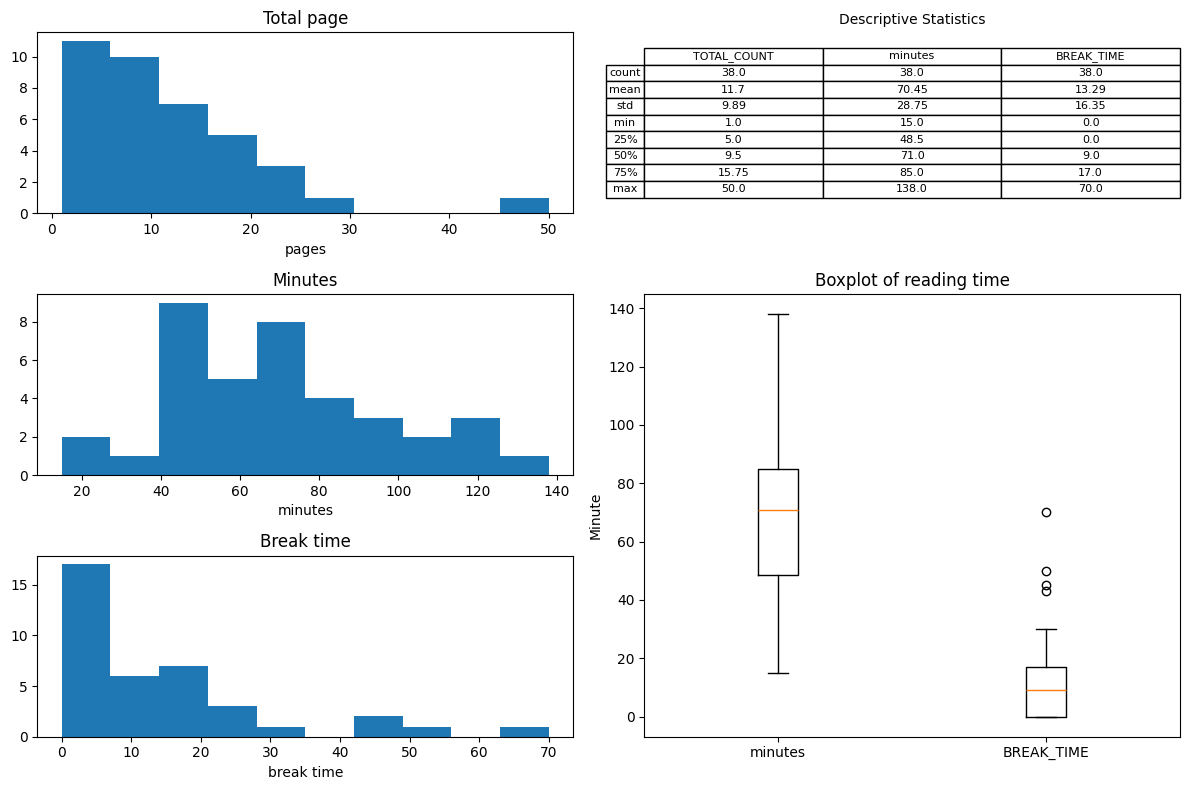

In [104]:
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig)

desc = ps[['TOTAL_COUNT', 'minutes', 'BREAK_TIME']].describe().round(2)

ax_table = fig.add_subplot(gs[0, 1])
ax_table.axis('off')
table = ax_table.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
for key, cell in table.get_celld().items():
    cell.set_text_props(ha='center', va='center')
ax_table.set_title('Descriptive Statistics', fontsize=10)

# --- Plot 1 ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ps['TOTAL_COUNT'])
ax1.set_xlabel("pages")
ax1.set_title("Total page")

# --- Plot 2 ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(ps['minutes'])
ax2.set_xlabel("minutes")
ax2.set_title("Minutes")

# --- Plot 3 ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(ps['BREAK_TIME'])
ax3.set_xlabel("break time")
ax3.set_title("Break time")

# --- Boxplot ---
ax4 = fig.add_subplot(gs[1:, 1])
ax4.boxplot(
    [ps['minutes'].dropna(), ps['BREAK_TIME'].dropna()],
    labels=['minutes', 'BREAK_TIME']
)
ax4.set_title('Boxplot of reading time')
ax4.set_ylabel('Minute')

plt.tight_layout()
plt.show()

# Technical and Vocational books

In [105]:
query = "SELECT * FROM `ml_reading` WHERE `ACTIVITY_CATEGORY` like 'technical_&_vocational'"
ps = pd.read_sql(query, engine)
ps.head()

,ACT_NAME,TOTAL_COUNT,minutes,BREAK_TIME,MENTAL_IN_BREAK,COMPREHENSION_DEPTH,PROOF_TRACE_ABILITY,READING_SPEED_FOR_PROOF,LINKING_TO_PREVIOUS_KNOWLEDGE,MENTAL_FATIGUE,...,INTERESTING_LEVEL,ACTIVITY_TAGS,ACTIVITY_CATEGORY,IS_RESEARCH,DEVICE,TRANSLATION,TRANSLATION_TYPE,ACTLOG_LOCATION,AROUSAL,FOCUS_LEVEL
0,The Full Stack Developer - Chris Northwood,9.0,50,0,none_break,strong,non_proof,non_proof,some_connections,normal,...,somewhat_interesting,mental,technical_&_vocational,0,laptop,full,macbook_translation,home,low,high
1,Programming Arduino Getting Started with Sketc...,3.0,76,45,neutral,basic,non_proof,non_proof,no_connection_made,fatigued,...,neutral,entertainment,technical_&_vocational,0,laptop,full,macbook_translation,home,high,low
2,Software Engineering - Ian Sommerville,5.0,54,0,none_break,good,non_proof,non_proof,some_connections,normal,...,very_boring,mental,technical_&_vocational,0,laptop,full,macbook_translation,home,high,medium
3,Computer Networking - James F. Kurose,8.0,69,17,neutral,strong,non_proof,non_proof,natural_linking,fresh,...,interesting,mental,technical_&_vocational,0,laptop,full,google_lens,home,high,high
4,Computer Networking - James F. Kurose,6.0,54,10,neutral,good,non_proof,non_proof,some_connections,fresh,...,somewhat_interesting,mental,technical_&_vocational,0,book,full,speech,home,high,high


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_16759/1826041369.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(


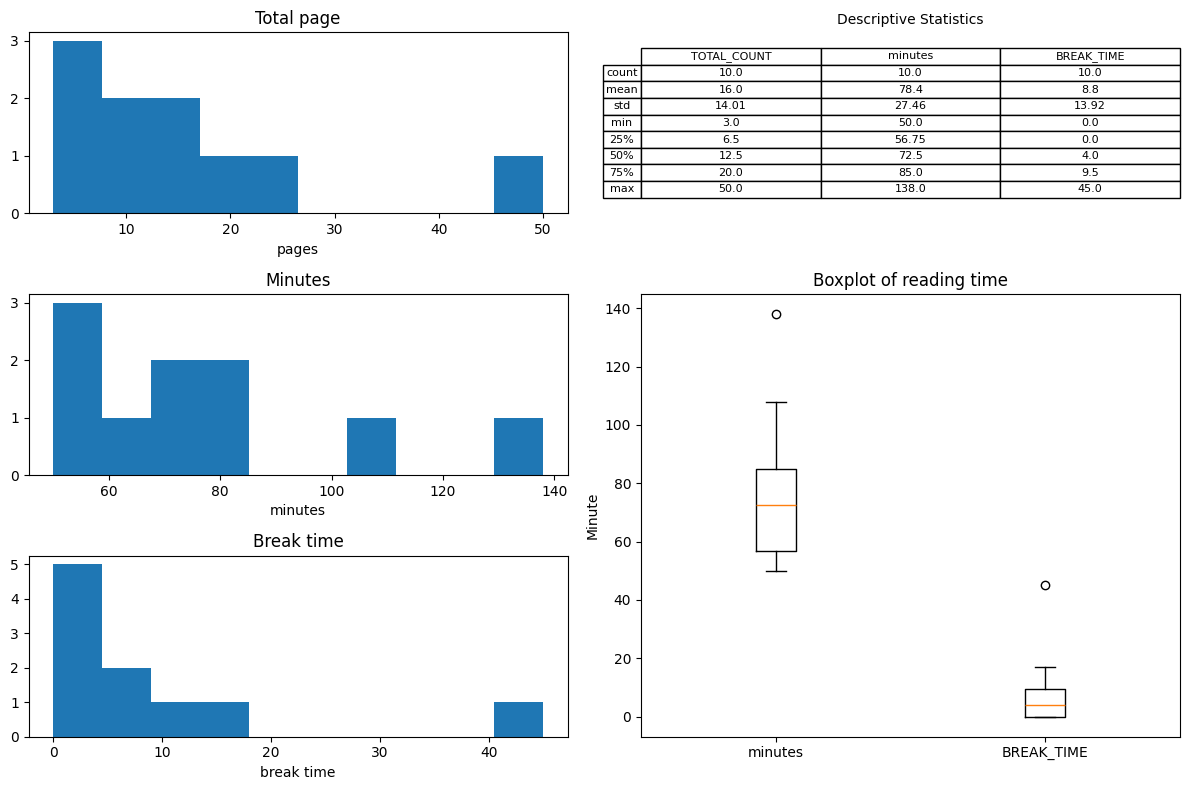

In [106]:
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig)

desc = ps[['TOTAL_COUNT', 'minutes', 'BREAK_TIME']].describe().round(2)

ax_table = fig.add_subplot(gs[0, 1])
ax_table.axis('off')
table = ax_table.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
for key, cell in table.get_celld().items():
    cell.set_text_props(ha='center', va='center')
ax_table.set_title('Descriptive Statistics', fontsize=10)

# --- Plot 1 ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ps['TOTAL_COUNT'])
ax1.set_xlabel("pages")
ax1.set_title("Total page")

# --- Plot 2 ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(ps['minutes'])
ax2.set_xlabel("minutes")
ax2.set_title("Minutes")

# --- Plot 3 ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(ps['BREAK_TIME'])
ax3.set_xlabel("break time")
ax3.set_title("Break time")

# --- Boxplot ---
ax4 = fig.add_subplot(gs[1:, 1])
ax4.boxplot(
    [ps['minutes'].dropna(), ps['BREAK_TIME'].dropna()],
    labels=['minutes', 'BREAK_TIME']
)
ax4.set_title('Boxplot of reading time')
ax4.set_ylabel('Minute')

plt.tight_layout()
plt.show()

Device: Laptop

In [107]:
query = """SELECT * FROM `ml_reading` 
            WHERE
            `ACTIVITY_CATEGORY` like 'technical_&_vocational'
            AND
            `DEVICE` like 'laptop'
        """
ps = pd.read_sql(query, engine)
ps.head()

,ACT_NAME,TOTAL_COUNT,minutes,BREAK_TIME,MENTAL_IN_BREAK,COMPREHENSION_DEPTH,PROOF_TRACE_ABILITY,READING_SPEED_FOR_PROOF,LINKING_TO_PREVIOUS_KNOWLEDGE,MENTAL_FATIGUE,...,INTERESTING_LEVEL,ACTIVITY_TAGS,ACTIVITY_CATEGORY,IS_RESEARCH,DEVICE,TRANSLATION,TRANSLATION_TYPE,ACTLOG_LOCATION,AROUSAL,FOCUS_LEVEL
0,The Full Stack Developer - Chris Northwood,9.0,50,0,none_break,strong,non_proof,non_proof,some_connections,normal,...,somewhat_interesting,mental,technical_&_vocational,0,laptop,full,macbook_translation,home,low,high
1,Programming Arduino Getting Started with Sketc...,3.0,76,45,neutral,basic,non_proof,non_proof,no_connection_made,fatigued,...,neutral,entertainment,technical_&_vocational,0,laptop,full,macbook_translation,home,high,low
2,Software Engineering - Ian Sommerville,5.0,54,0,none_break,good,non_proof,non_proof,some_connections,normal,...,very_boring,mental,technical_&_vocational,0,laptop,full,macbook_translation,home,high,medium
3,Computer Networking - James F. Kurose,8.0,69,17,neutral,strong,non_proof,non_proof,natural_linking,fresh,...,interesting,mental,technical_&_vocational,0,laptop,full,google_lens,home,high,high
4,Systems analysis & design in a changing world ...,17.0,85,0,none_break,good,non_proof,non_proof,some_connections,fresh,...,neutral,mental,technical_&_vocational,0,laptop,full,speech,library,high,high


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_16759/1826041369.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(


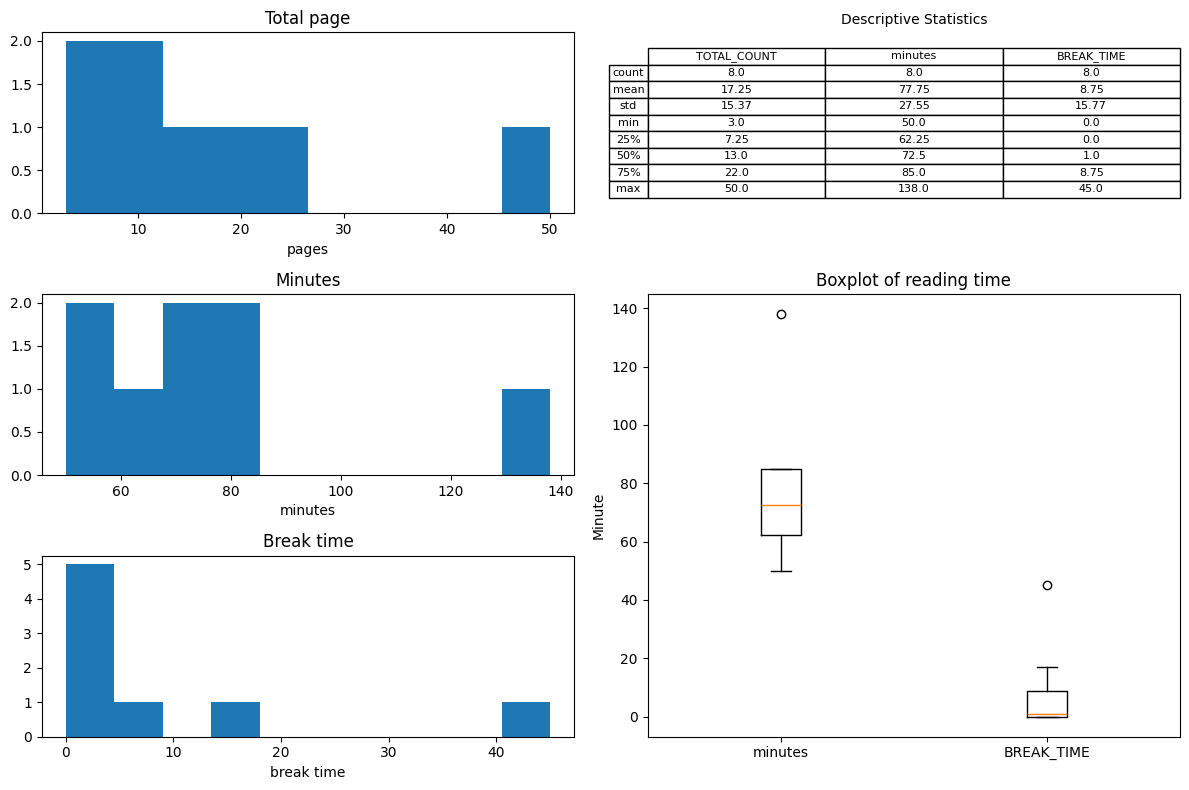

In [108]:
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig)

desc = ps[['TOTAL_COUNT', 'minutes', 'BREAK_TIME']].describe().round(2)

ax_table = fig.add_subplot(gs[0, 1])
ax_table.axis('off')
table = ax_table.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
for key, cell in table.get_celld().items():
    cell.set_text_props(ha='center', va='center')
ax_table.set_title('Descriptive Statistics', fontsize=10)

# --- Plot 1 ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ps['TOTAL_COUNT'])
ax1.set_xlabel("pages")
ax1.set_title("Total page")

# --- Plot 2 ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(ps['minutes'])
ax2.set_xlabel("minutes")
ax2.set_title("Minutes")

# --- Plot 3 ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(ps['BREAK_TIME'])
ax3.set_xlabel("break time")
ax3.set_title("Break time")

# --- Boxplot ---
ax4 = fig.add_subplot(gs[1:, 1])
ax4.boxplot(
    [ps['minutes'].dropna(), ps['BREAK_TIME'].dropna()],
    labels=['minutes', 'BREAK_TIME']
)
ax4.set_title('Boxplot of reading time')
ax4.set_ylabel('Minute')

plt.tight_layout()
plt.show()

# Academic books

In [109]:
query = "SELECT * FROM `ml_reading` WHERE `ACTIVITY_CATEGORY` like 'academic'"
ps = pd.read_sql(query, engine)
ps.head()

,ACT_NAME,TOTAL_COUNT,minutes,BREAK_TIME,MENTAL_IN_BREAK,COMPREHENSION_DEPTH,PROOF_TRACE_ABILITY,READING_SPEED_FOR_PROOF,LINKING_TO_PREVIOUS_KNOWLEDGE,MENTAL_FATIGUE,...,INTERESTING_LEVEL,ACTIVITY_TAGS,ACTIVITY_CATEGORY,IS_RESEARCH,DEVICE,TRANSLATION,TRANSLATION_TYPE,ACTLOG_LOCATION,AROUSAL,FOCUS_LEVEL
0,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,12.0,75,0,none_break,strong,non_proof,non_proof,some_connections,fresh,...,interesting,mental,academic,0,smartphone,full,google_lens,outdoor,low,medium
1,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,5.0,90,0,none_break,strong,non_proof,non_proof,natural_linking,fresh,...,somewhat_interesting,mental,academic,0,laptop,full,google_lens,home,neutral,medium
2,Statistics for Business & Economics,6.0,43,17,calm,good,non_proof,non_proof,some_connections,normal,...,somewhat_interesting,mental,academic,0,laptop,minimal,macbook_translation,home,neutral,high
3,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,3.0,24,0,none_break,good,non_proof,non_proof,natural_linking,very_fresh,...,extremely_interesting,mental,academic,0,laptop,partial,google_lens,home,slightly_low,medium
4,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,8.0,75,0,none_break,good,non_proof,non_proof,some_connections,normal,...,somewhat_interesting,mental,academic,0,laptop,partial,google_lens,home,high,very_low


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_16759/1826041369.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(


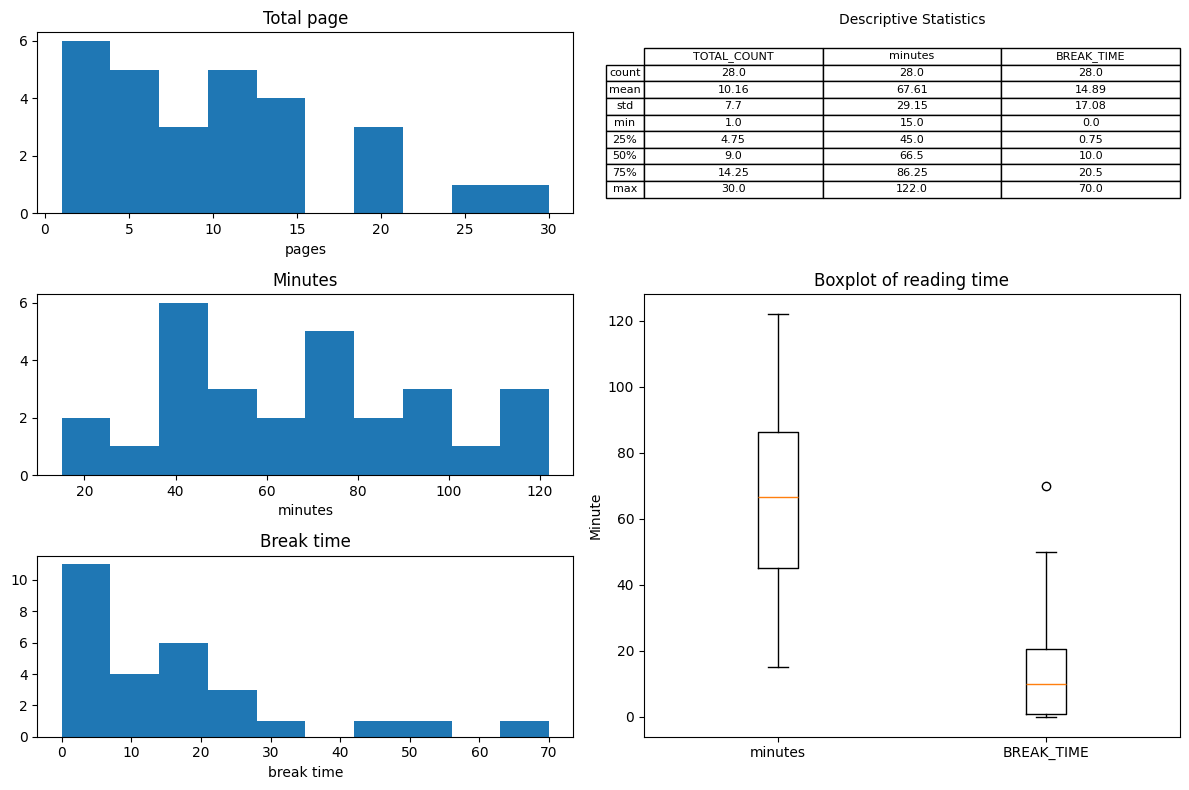

In [110]:
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig)

desc = ps[['TOTAL_COUNT', 'minutes', 'BREAK_TIME']].describe().round(2)

ax_table = fig.add_subplot(gs[0, 1])
ax_table.axis('off')
table = ax_table.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
for key, cell in table.get_celld().items():
    cell.set_text_props(ha='center', va='center')
ax_table.set_title('Descriptive Statistics', fontsize=10)

# --- Plot 1 ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ps['TOTAL_COUNT'])
ax1.set_xlabel("pages")
ax1.set_title("Total page")

# --- Plot 2 ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(ps['minutes'])
ax2.set_xlabel("minutes")
ax2.set_title("Minutes")

# --- Plot 3 ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(ps['BREAK_TIME'])
ax3.set_xlabel("break time")
ax3.set_title("Break time")

# --- Boxplot ---
ax4 = fig.add_subplot(gs[1:, 1])
ax4.boxplot(
    [ps['minutes'].dropna(), ps['BREAK_TIME'].dropna()],
    labels=['minutes', 'BREAK_TIME']
)
ax4.set_title('Boxplot of reading time')
ax4.set_ylabel('Minute')

plt.tight_layout()
plt.show()

Device: Laptop

In [111]:
query = "SELECT * FROM `ml_reading` WHERE `ACTIVITY_CATEGORY` like 'academic' and `DEVICE` like 'laptop'"
ps = pd.read_sql(query, engine)
ps.head()

,ACT_NAME,TOTAL_COUNT,minutes,BREAK_TIME,MENTAL_IN_BREAK,COMPREHENSION_DEPTH,PROOF_TRACE_ABILITY,READING_SPEED_FOR_PROOF,LINKING_TO_PREVIOUS_KNOWLEDGE,MENTAL_FATIGUE,...,INTERESTING_LEVEL,ACTIVITY_TAGS,ACTIVITY_CATEGORY,IS_RESEARCH,DEVICE,TRANSLATION,TRANSLATION_TYPE,ACTLOG_LOCATION,AROUSAL,FOCUS_LEVEL
0,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,5.0,90,0,none_break,strong,non_proof,non_proof,natural_linking,fresh,...,somewhat_interesting,mental,academic,0,laptop,full,google_lens,home,neutral,medium
1,Statistics for Business & Economics,6.0,43,17,calm,good,non_proof,non_proof,some_connections,normal,...,somewhat_interesting,mental,academic,0,laptop,minimal,macbook_translation,home,neutral,high
2,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,3.0,24,0,none_break,good,non_proof,non_proof,natural_linking,very_fresh,...,extremely_interesting,mental,academic,0,laptop,partial,google_lens,home,slightly_low,medium
3,A BOOK OF ABSTRACT ALGEBRA - Charles C. Pinter,8.0,75,0,none_break,good,non_proof,non_proof,some_connections,normal,...,somewhat_interesting,mental,academic,0,laptop,partial,google_lens,home,high,very_low
4,Linear Algebra and Its Applications - David C....,10.0,48,3,neutral,strong,non_proof,non_proof,natural_linking,normal,...,neutral,mental,academic,0,laptop,minimal,dictionary,home,slightly_high,high


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_16759/1826041369.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(


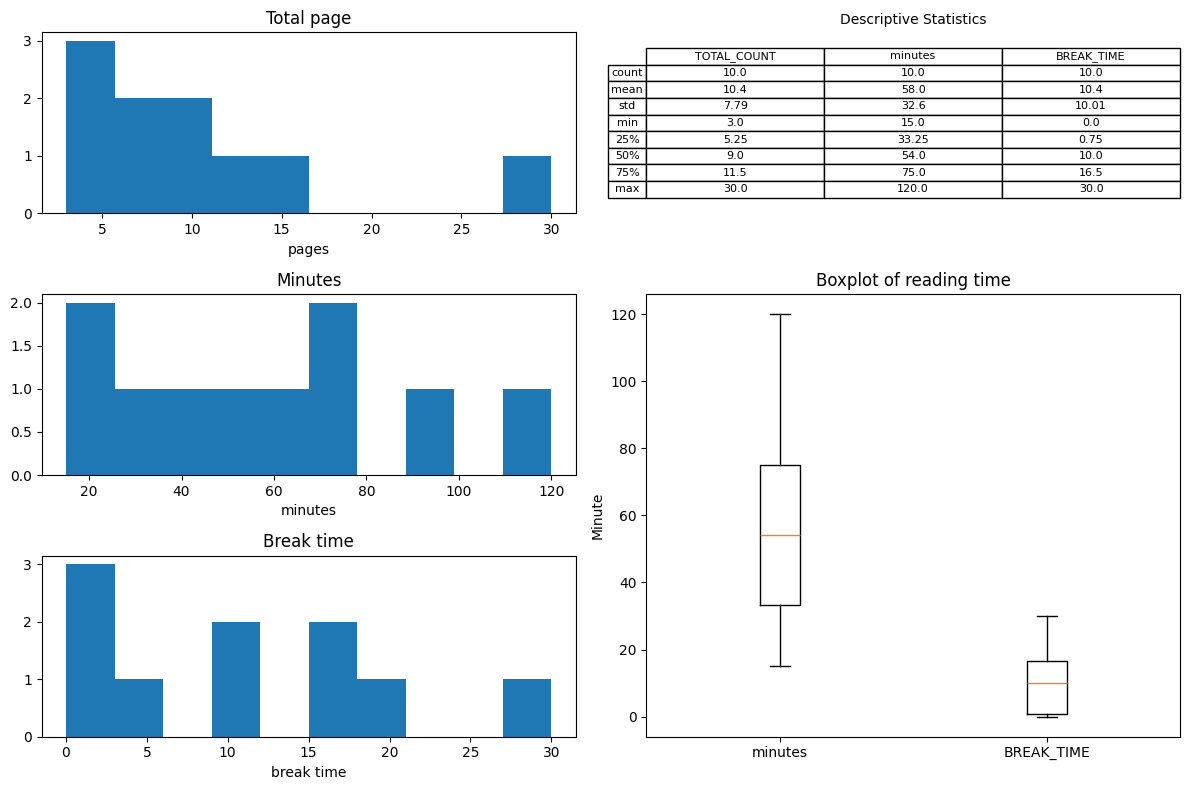

In [112]:
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig)

desc = ps[['TOTAL_COUNT', 'minutes', 'BREAK_TIME']].describe().round(2)

ax_table = fig.add_subplot(gs[0, 1])
ax_table.axis('off')
table = ax_table.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
for key, cell in table.get_celld().items():
    cell.set_text_props(ha='center', va='center')
ax_table.set_title('Descriptive Statistics', fontsize=10)

# --- Plot 1 ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ps['TOTAL_COUNT'])
ax1.set_xlabel("pages")
ax1.set_title("Total page")

# --- Plot 2 ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(ps['minutes'])
ax2.set_xlabel("minutes")
ax2.set_title("Minutes")

# --- Plot 3 ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(ps['BREAK_TIME'])
ax3.set_xlabel("break time")
ax3.set_title("Break time")

# --- Boxplot ---
ax4 = fig.add_subplot(gs[1:, 1])
ax4.boxplot(
    [ps['minutes'].dropna(), ps['BREAK_TIME'].dropna()],
    labels=['minutes', 'BREAK_TIME']
)
ax4.set_title('Boxplot of reading time')
ax4.set_ylabel('Minute')

plt.tight_layout()
plt.show()